In [1]:
# Cell 1: Load Model, Data, and Initialize SHAP
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import shap
import re
import warnings
warnings.filterwarnings('ignore')

print("--- Step 1: Loading Assets ---")

# 1. Load the Model
model_path = '../saved_models/final_microloan_model.pkl'
model = joblib.load(model_path)
print(" Final Model Loaded")

# 2. Load the Data
df = pd.read_csv('application_train_fully_preprocessed.csv')
df = df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

X = df.drop(columns=['TARGET'])
y = df['TARGET']

# 3. Take a representative sample of 1000 rows to speed up SHAP calculations
X_sample = X.sample(n=1000, random_state=42)
y_sample = y.loc[X_sample.index]
print(f" Data Sampled: {X_sample.shape}")

# 4. Initialize the SHAP TreeExplainer (optimized for LightGBM)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# For LightGBM binary classification, SHAP returns a list of two arrays [Class 0, Class 1].
# We only care about Class 1 (the probability of Defaulting)
if isinstance(shap_values, list):
    shap_values_default = shap_values[1]
else:
    shap_values_default = shap_values

print(" SHAP Values Calculated!")

c:\neww\FYP\microloan-credit-scoring\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Step 1: Loading Assets ---
 Final Model Loaded
 Data Sampled: (1000, 161)
 SHAP Values Calculated!


--- Step 2: Generating Global Model Explanation ---
How to read this chart:
- Feature importance goes from top to bottom.
- Red dots = High value for that feature (e.g., High Annuity/Income Ratio).
- Blue dots = Low value for that feature.
- Dots pushed to the RIGHT increase the risk of default.
- Dots pushed to the LEFT decrease the risk of default.


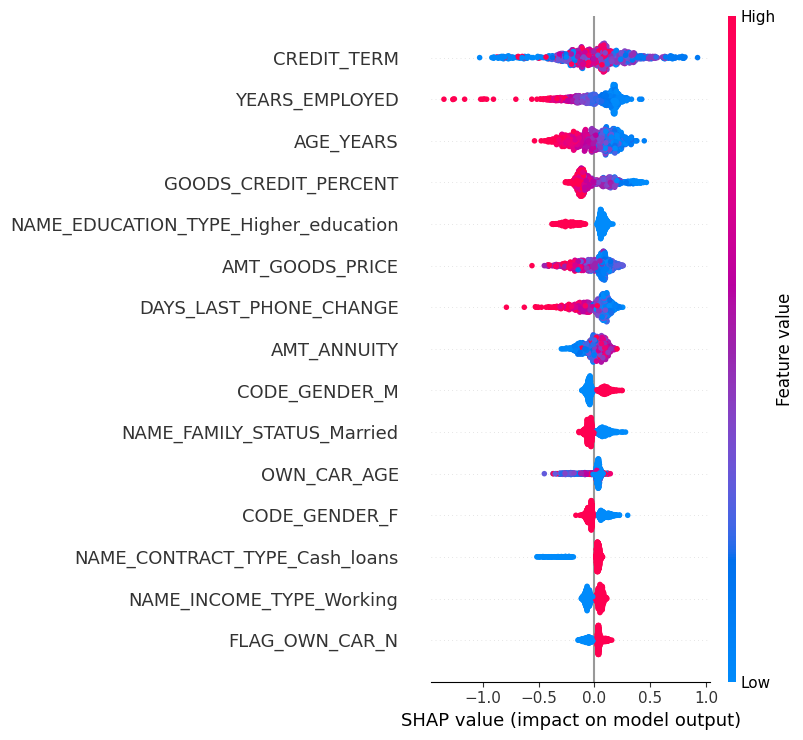

In [2]:
# Cell 2: Global Explanation (Summary Plot)
import matplotlib.pyplot as plt

print("--- Step 2: Generating Global Model Explanation ---")
print("How to read this chart:")
print("- Feature importance goes from top to bottom.")
print("- Red dots = High value for that feature (e.g., High Annuity/Income Ratio).")
print("- Blue dots = Low value for that feature.")
print("- Dots pushed to the RIGHT increase the risk of default.")
print("- Dots pushed to the LEFT decrease the risk of default.")

plt.figure(figsize=(12, 8))
# The summary plot automatically handles rendering
shap.summary_plot(shap_values_default, X_sample, max_display=15)

--- Step 3: Generating Local Explanation ---
Analyzing Applicant Index: 222505
Predicted Default Probability: 85.06%


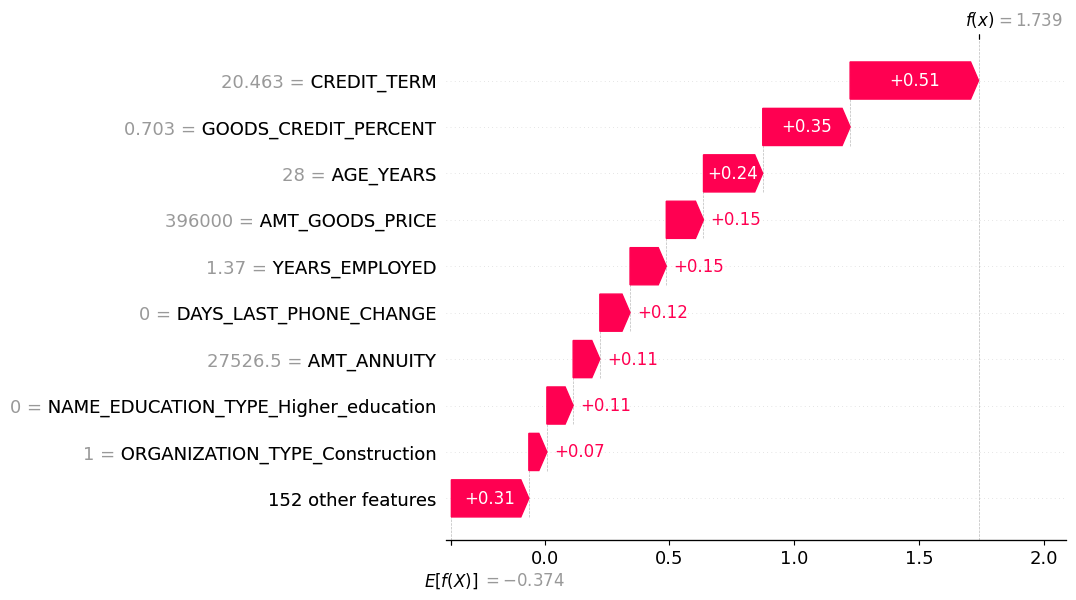

In [3]:
# Cell 3: Local Explanation (Waterfall Plot for a Single Applicant)

print("--- Step 3: Generating Local Explanation ---")

# 1. Find an applicant in our sample that the model flagged as high risk
probabilities = model.predict_proba(X_sample)[:, 1]
high_risk_index = np.argmax(probabilities) # Get the riskiest applicant
applicant_data = X_sample.iloc[high_risk_index]
applicant_risk = probabilities[high_risk_index]

print(f"Analyzing Applicant Index: {X_sample.index[high_risk_index]}")
print(f"Predicted Default Probability: {applicant_risk:.2%}")

# 2. Extract SHAP values for just this ONE person
if isinstance(shap_values, list):
    shap_values_single = explainer(X_sample)[high_risk_index, :, 1]
else:
    shap_values_single = explainer(X_sample)[high_risk_index]

# 3. Plot the Waterfall chart
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_single, max_display=10)

In [14]:
# Cell 4 : Dynamic Translation using a Feature Dictionary
import pandas as pd
import json
import os

print("--- Step 4: Generating Dynamic Actionable Recommendations ---")

# 1. Initialize an empty dictionary to prevent NameError if the file fails to load
feature_dict = {}

# 2. Fix the path. Since your notebook is in 'backend', we just look inside 'config'
current_dir = os.getcwd()
config_path = os.path.abspath(os.path.join(current_dir, '..', 'config', 'xai_feature_dictionary.json'))

print(f"Attempting to load config from: {config_path}")

# Load the dictionary with a safety check
if os.path.exists(config_path):
    with open(config_path, 'r') as file:
        feature_dict = json.load(file)
    print("Dictionary Loaded Successfully!")
else:
    print("ERROR: File not found. Using the fallback terminology.")

# 3. Get the top risk factors from SHAP
feature_names = X_sample.columns
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Impact': shap_values_single.values, 
    'Applicant_Value': applicant_data.values  
})
top_risk_factors = shap_df.sort_values(by='SHAP_Impact', ascending=False).head(3)

print(f"Decision: REJECTED (Risk Probability: {applicant_risk:.1%})\n")
print("--- Recommended Actions for the Applicant ---")

# 4. Translate technical features to human-readable advice
for index, row in top_risk_factors.iterrows():
    raw_feature = row['Feature']
    
    # Look up the feature in the dictionary. 
    # If it's missing, use a clean fallback dictionary.
    translation = feature_dict.get(raw_feature, {
        "display_name": raw_feature.replace('_', ' ').title(), 
        "reason": "This specific financial metric flagged our automated risk parameters.",
        "action": "Discuss this metric with a verified loan officer for alternative options."
    })
    
    # Print the clean, user-facing output
    print(f"Factor: {translation['display_name']}")
    print(f"Reason: {translation['reason']}")
    print(f"Action: {translation['action']}\n")

--- Step 4: Generating Dynamic Actionable Recommendations ---
Attempting to load config from: c:\neww\FYP\microloan-credit-scoring\backend\config\xai_feature_dictionary.json
Dictionary Loaded Successfully!
Decision: REJECTED (Risk Probability: 85.1%)

--- Recommended Actions for the Applicant ---
Factor: Requested Loan Term
Reason: The requested loan repayment period is severely misaligned with our safety parameters.
Action: Adjust the requested loan amount or monthly annuity to fit a standard 12-36 month term.

Factor: Goods-to-Credit Ratio
Reason: The requested loan amount deviates significantly from the actual price of the goods being financed.
Action: Ensure the requested loan amount closely matches the purchase price, or increase your upfront down payment.

Factor: Age Demographics
Reason: Statistical risk associated with this age bracket.
Action: Secure a guarantor or co-signer for the loan application.

